# Error Diffusion: Halftoning and Perceptual Dithering

**Halftoning** is the problem of representing a continuous-tone image using only binary (black/white) pixels, while preserving the perceived tonal values to the human eye. Printers and early displays operate in binary — how can they reproduce the full gray scale?

The key insight of **error diffusion** (Floyd and Steinberg, 1976) is: when a pixel is rounded to 0 or 1, the **quantization error** is not discarded but spread to neighbouring pixels that have not yet been processed. This way the average value over a small neighbourhood matches the original gray level, exploiting the spatial low-pass filtering of the human visual system.

## Floyd–Steinberg algorithm

Scan pixels in raster order (left-to-right, top-to-bottom). At pixel $(i,j)$:
1. **Quantize**: $g_{ij} \leftarrow \mathbf{1}[g_{ij} > 0.5]$ (threshold).
2. **Compute error**: $e = f_{ij} - g_{ij}$ (original minus quantized).
3. **Diffuse error** to four future neighbours with weights
$$
\frac{1}{16}\begin{bmatrix} . & . & 7 \\ 3 & 5 & 1 \end{bmatrix}
$$
where the current pixel is at position marked $.$.

The weights sum to 1, so the total error is conserved. The result is a **blue-noise** dither pattern: errors are spread uniformly in all directions, avoiding visible low-frequency artifacts.

## Other dithering methods

- **Simple threshold**: $g_{ij} = \mathbf{1}[f_{ij} > 0.5]$. Produces contouring artifacts in smooth regions.
- **Ordered (Bayer) dithering**: compare each pixel to a spatially varying threshold from a precomputed matrix. Creates a structured, regular dot pattern.
- **Random dithering**: add uniform noise before thresholding. Eliminates contouring but introduces grainy random texture.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown, FloatSlider

plt.rcParams["figure.dpi"] = 120

## Test images

We use three synthetic gray-scale images with different characteristics:
- **Linear ramp**: smoothly varying from 0 to 1 — reveals contouring artifacts clearly.
- **Circles**: sharp edges on smooth backgrounds.
- **Sinusoidal**: frequency content that exercises the spectral behavior of each algorithm.

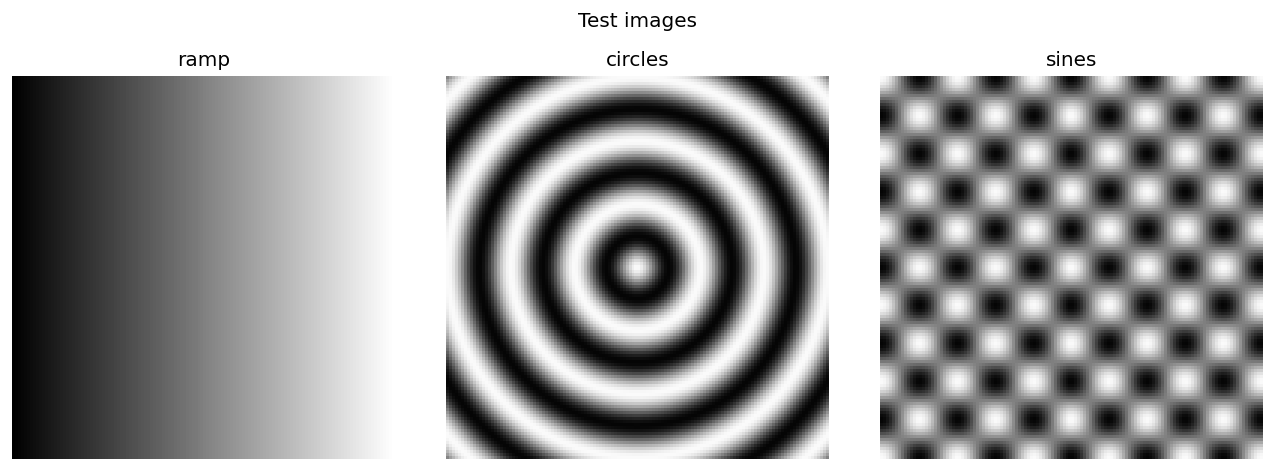

In [2]:
n = 128
x = np.linspace(0, 1, n)
X, Y = np.meshgrid(x, x)

ramp    = X.copy()
circles = 0.5 + 0.48 * np.cos(2*np.pi * np.sqrt((X-0.5)**2 + (Y-0.5)**2) * 6)
circles = np.clip(circles, 0, 1)
sines   = 0.5 + 0.48 * np.cos(2*np.pi*5*X) * np.cos(2*np.pi*5*Y)

imgs = {"ramp": ramp, "circles": circles, "sines": sines}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
for ax, (name, img) in zip(axes, imgs.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(name); ax.axis("off")
fig.suptitle("Test images", y=1.02)
plt.tight_layout()
plt.show()

## Dithering algorithms

We implement four methods: simple thresholding, random dithering, ordered Bayer dithering (4×4 matrix), and Floyd–Steinberg error diffusion.

In [3]:
# Bayer 4x4 threshold matrix (normalized to [0,1])
BAYER4 = np.array([
    [ 0,  8,  2, 10],
    [12,  4, 14,  6],
    [ 3, 11,  1,  9],
    [15,  7, 13,  5],
], dtype=float) / 16.0


def threshold(img):
    return (img > 0.5).astype(float)


def random_dither(img, seed=0):
    rng = np.random.default_rng(seed)
    noise = rng.uniform(-0.5, 0.5, img.shape)
    return (img + noise > 0.5).astype(float)


def bayer_dither(img):
    n = img.shape[0]
    tile = np.tile(BAYER4, (n // 4 + 1, n // 4 + 1))[:n, :n]
    return (img > tile).astype(float)


def floyd_steinberg(img):
    g = img.astype(float).copy()
    rows, cols = g.shape
    for i in range(rows):
        for j in range(cols):
            old = g[i, j]
            new = float(old > 0.5)
            g[i, j] = new
            err = old - new
            if j + 1 < cols:
                g[i, j+1]   += err * 7 / 16
            if i + 1 < rows:
                if j > 0:
                    g[i+1, j-1] += err * 3 / 16
                g[i+1, j]   += err * 5 / 16
                if j + 1 < cols:
                    g[i+1, j+1] += err * 1 / 16
    return (g > 0.5).astype(float)


print("All dithering methods ready.")

All dithering methods ready.


## Comparison on all test images

We apply all four methods to all three test images. Observe:
- **Threshold** shows obvious contouring (Mach bands) on the ramp.
- **Random** eliminates contouring but introduces grainy noise.
- **Bayer** shows a regular dot-screen pattern — structured but clean.
- **Floyd–Steinberg** distributes dots in an irregular, visually smooth blue-noise pattern.

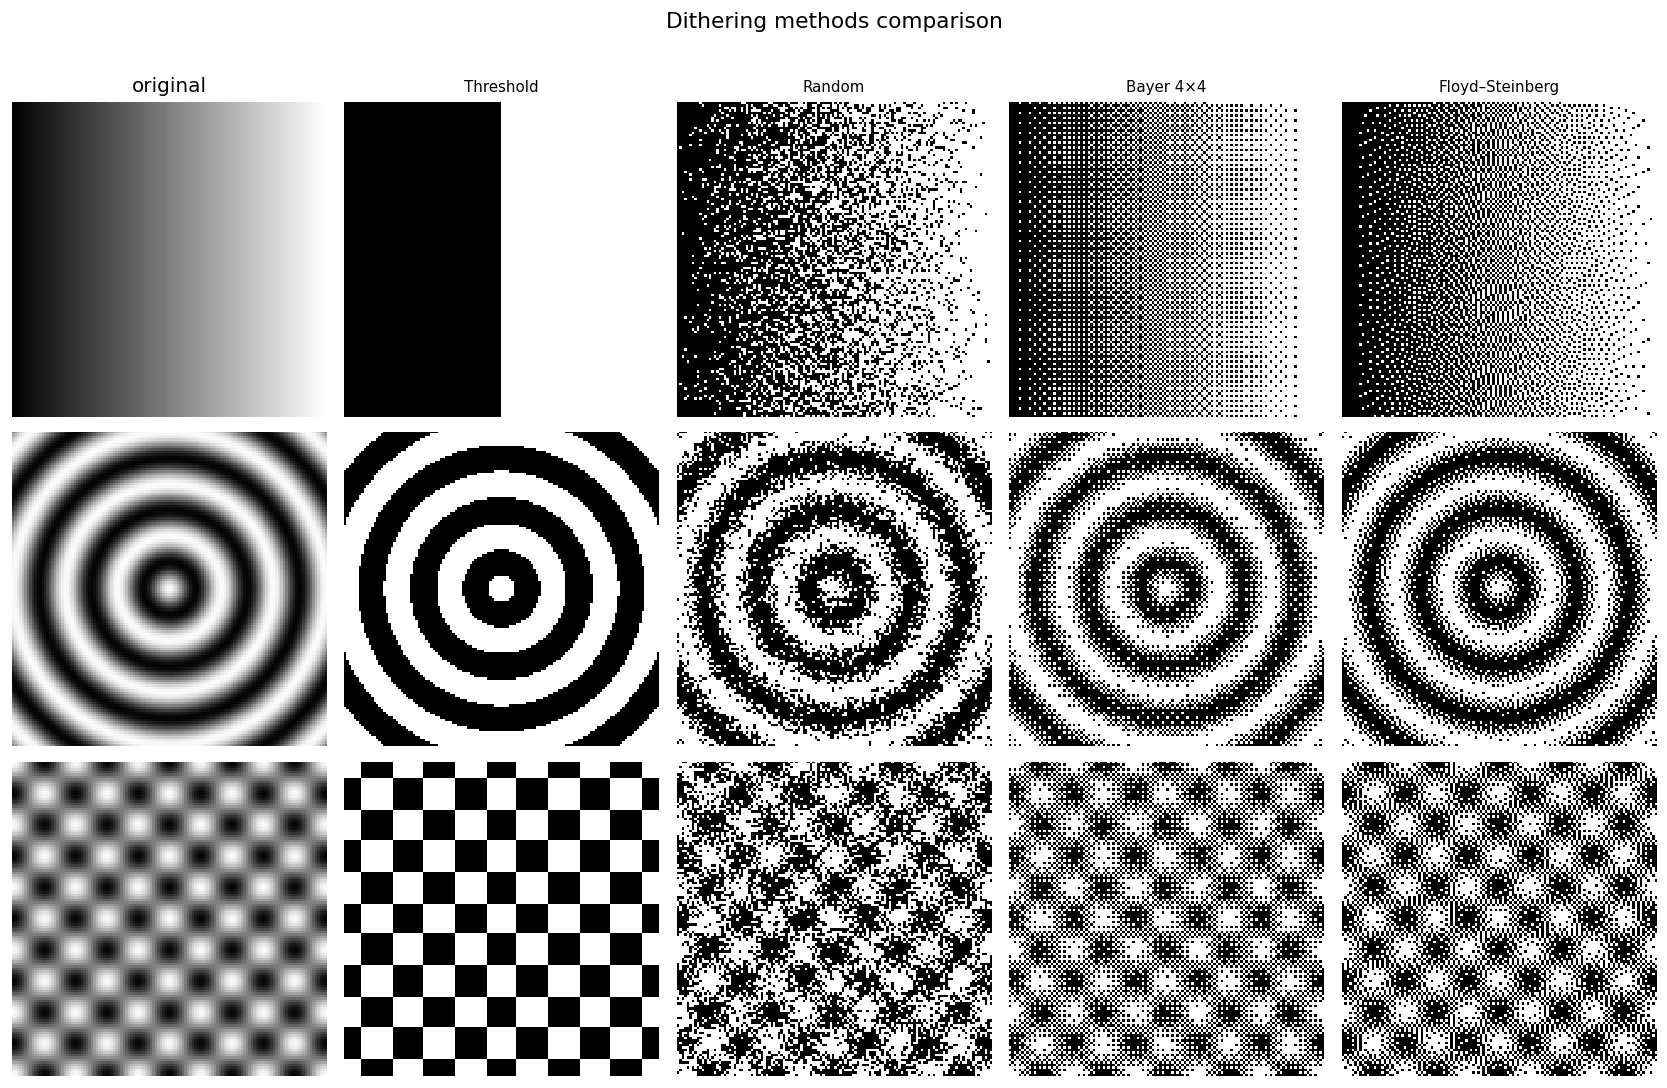

In [4]:
methods = [
    ("Threshold",      threshold),
    ("Random",         random_dither),
    ("Bayer 4×4",      bayer_dither),
    ("Floyd–Steinberg",floyd_steinberg),
]

fig, axes = plt.subplots(len(imgs), len(methods) + 1,
                          figsize=(14, 9))
for row, (img_name, img) in enumerate(imgs.items()):
    axes[row, 0].imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[row, 0].set_title("original" if row == 0 else "")
    axes[row, 0].set_ylabel(img_name, fontsize=10)
    axes[row, 0].axis("off")
    for col, (mname, mfunc) in enumerate(methods):
        out = mfunc(img)
        axes[row, col+1].imshow(out, cmap="gray", vmin=0, vmax=1,
                                 interpolation="nearest")
        if row == 0:
            axes[row, col+1].set_title(mname, fontsize=9)
        axes[row, col+1].axis("off")
fig.suptitle("Dithering methods comparison", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Spectral analysis: noise color

The human visual system acts as a low-pass filter: it averages intensity over a small neighbourhood. A good dithering scheme spreads quantization error into **high spatial frequencies** (blue noise), invisible to the eye. We examine the power spectral density (PSD) of the error $g - f$ for each method.

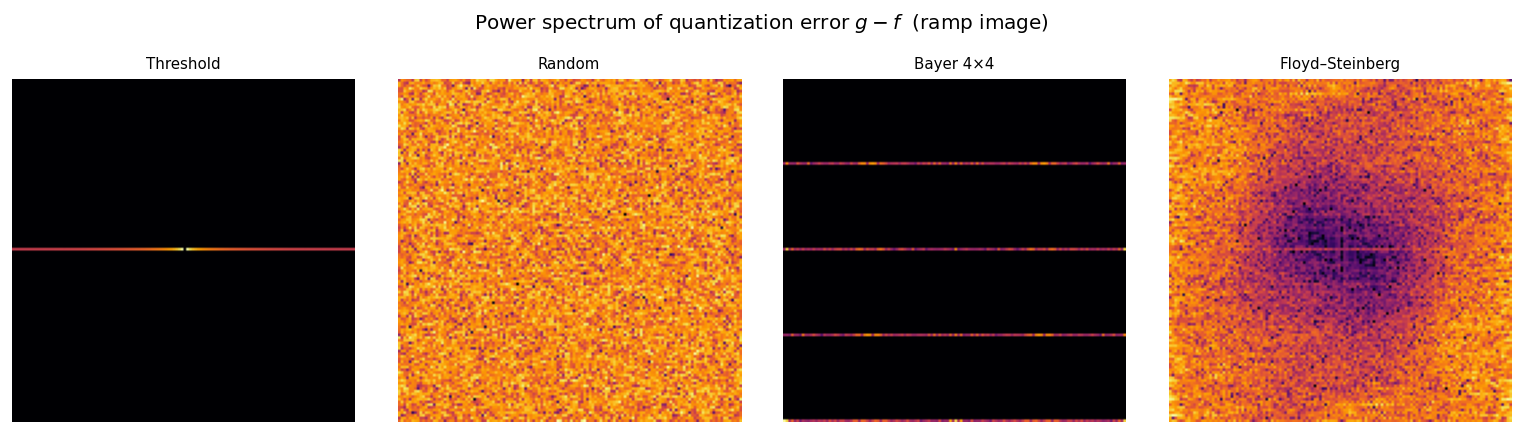

In [5]:
img_test = ramp   # use the ramp for clearest spectral signature

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ax, (mname, mfunc) in zip(axes, methods):
    out = mfunc(img_test)
    err = out - img_test
    psd = np.abs(np.fft.fftshift(np.fft.fft2(err)))**2
    ax.imshow(np.log1p(psd), cmap="inferno", origin="lower")
    ax.set_title(mname, fontsize=9)
    ax.axis("off")
fig.suptitle("Power spectrum of quantization error $g - f$  (ramp image)", y=1.02)
plt.tight_layout()
plt.show()

## Interactive Floyd–Steinberg step-by-step

Watch the error diffusion unfold row by row. The slider controls how many rows have been processed. Notice how the diffused error accumulates ahead of the wavefront.

In [6]:
def floyd_steinberg_partial(img, n_rows):
    g = img.astype(float).copy()
    rows, cols = g.shape
    n_rows = min(n_rows, rows)
    for i in range(n_rows):
        for j in range(cols):
            old = g[i, j]
            new = float(old > 0.5)
            g[i, j] = new
            err = old - new
            if j + 1 < cols:
                g[i, j+1]   += err * 7 / 16
            if i + 1 < rows:
                if j > 0:
                    g[i+1, j-1] += err * 3 / 16
                g[i+1, j]   += err * 5 / 16
                if j + 1 < cols:
                    g[i+1, j+1] += err * 1 / 16
    return g


def show_partial(image="circles", n_rows=32):
    img_s = imgs[image]
    g = floyd_steinberg_partial(img_s, n_rows)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img_s, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[0].axhline(n_rows, color="r", lw=1.5)
    axes[0].set_title("original"); axes[0].axis("off")

    axes[1].imshow(np.where(
            np.arange(n)[:, None] < n_rows,
            np.round(g), g),
        cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[1].axhline(n_rows, color="r", lw=1.5)
    axes[1].set_title(f"dithered (rows 0–{n_rows})"); axes[1].axis("off")

    # residual error map
    axes[2].imshow(g - img_s, cmap="RdBu_r", vmin=-0.5, vmax=0.5,
                   interpolation="nearest")
    axes[2].axhline(n_rows, color="k", lw=1.5)
    axes[2].set_title("accumulated error $g - f$"); axes[2].axis("off")
    plt.tight_layout(); plt.show()

interact(
    show_partial,
    image=Dropdown(options=list(imgs.keys()), description="image"),
    n_rows=IntSlider(value=32, min=1, max=n, step=1, description="rows"),
) if False else interact(
    show_partial,
    image=Dropdown(options=list(imgs.keys()), description="image"),
    n_rows=__import__('ipywidgets').IntSlider(value=32, min=1, max=n, step=1, description="rows"),
);

interactive(children=(Dropdown(description='image', options=('ramp', 'circles', 'sines'), value='ramp'), IntSl…

## Bibliographical resources

- Floyd, R. W. and Steinberg, L. (1976). An adaptive algorithm for spatial grayscale. *Proceedings of the Society of Information Display*, 17(2), 75–77.
- Bayer, B. E. (1973). An optimum method for two-level rendition of continuous-tone pictures. *IEEE International Conference on Communications*, 26.
- Ulichney, R. (1987). *Digital Halftoning*. MIT Press.
- Ostromoukhov, V. (2001). A simple and efficient error-diffusion algorithm. *SIGGRAPH Proceedings*, 567–572.
- Lau, D. L. and Arce, G. R. (2008). *Modern Digital Halftoning* (2nd ed.). CRC Press.